## 1. Pembacaan dan Inspeksi Data Mentah

Tahap ini bertujuan untuk mengenali struktur dataset, tipe data, serta mengeksplorasi data mentah yang diekspor dari WhatsApp pada periode 2025-10-01 hingga 2026-06-13.
File `master_chat_wa.csv` dimuat ke dalam struktur *DataFrame* untuk menganalisis informasi atribut, menampilkan observasi awal, dan mendeteksi anomali atau *noise* pada frekuensi isi pesan.

In [17]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# 1. Memuat dataset observasi mentah ke dalam DataFrame
df_raw = pd.read_csv('master_chat_wa.csv')
print("--- 1. Informasi Struktur Dataset Mentah ---")
df_raw.info()

print("\n--- 2. Observasi 5 Baris Pertama Dataset ---")
display(df_raw.head())

print("\n--- 3. 15 Frekuensi Observasi Teks Tertinggi (Deteksi Noise) ---")
print(df_raw['Message Body'].value_counts().head(15))

--- 1. Informasi Struktur Dataset Mentah ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3502 entries, 0 to 3501
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Country         3502 non-null   object
 1   Phone Number    3502 non-null   int64 
 2   Formatted Name  3502 non-null   object
 3   Display Name    3418 non-null   object
 4   Message Time    3502 non-null   object
 5   Message Type    3502 non-null   object
 6   Message Body    3447 non-null   object
 7   Message Id      3502 non-null   object
dtypes: int64(1), object(7)
memory usage: 219.0+ KB

--- 2. Observasi 5 Baris Pertama Dataset ---


,Country,Phone Number,Formatted Name,Display Name,Message Time,Message Type,Message Body,Message Id
0,Indonesia,6285752887496,Anda,anugerahcomputer4,2026-04-27 12:10:50,chat,【IMAGE】,true_211622366855206@lid_AC2292D9378555369E125...
1,Indonesia,6285752887496,Anda,anugerahcomputer4,2026-04-27 12:10:55,chat,Anugerah komputer,true_211622366855206@lid_ACEC981E86F9304411889...
2,Indonesia,6281156701235,+62 811-5670-1235,NaN,2026-04-27 16:13:57,chat,Oke bg,false_211622366855206@lid_ACCC7B568284EA7BDECA...
3,Indonesia,6281156701235,+62 811-5670-1235,NaN,2026-04-29 10:17:27,chat,Bg berapa kemarin harganya ya,false_211622366855206@lid_AC0056ED0CC9DBDAF77A...
4,Indonesia,6285752887496,Anda,anugerahcomputer4,2026-04-29 10:18:06,chat,Nnti tnya y bg blom dtg bos nya,true_211622366855206@lid_AC4ECED0F39172D7E0788...



--- 3. 15 Frekuensi Observasi Teks Tertinggi (Deteksi Noise) ---
Message Body
【IMAGE】              331
Anugerah komputer     59
Oke kak               45
Ok                    41
Oke bang              36
Iya kak               24
Ok bg                 17
Anugerah Computer     16
Ok kk                 15
Okee kak              15
Oke bg                14
【VIDEO】               13
Bisa kak              13
oke bang              11
Iya bang               7
Name: count, dtype: int64


## 2. Penyaringan Data dan Pembersihan Derau (*Data Filtering and Noise Removal*)

**Tujuan:** Memisahkan data observasi yang relevan untuk analisis dari data yang tidak memiliki nilai informasi linguistik bagi model pemrosesan bahasa alami (NLP).
**Prosedur:**
1. Mengidentifikasi dan memfilter pesan pelanggan (inbound) melalui atribut `Message Id` yang ditandai dengan `false_`.
2. Mengeliminasi data multimedia (seperti `【IMAGE】` atau `【VIDEO】`) menggunakan ekspresi reguler (*Regular Expression*).
3. Menghapus observasi dengan nilai kosong (*missing values*). Frekuensi observasi ganda tetap dipertahankan pada tahap ini untuk merepresentasikan distribusi percakapan secara alami.

In [18]:
import re

print("=== TAHAP 2: PENYARINGAN & PEMBERSIHAN DERAU ===")

# Prosedur 1: Memfilter observasi spesifik untuk pesan pelanggan (inbound)
df_customer = df_raw[df_raw['Message Id'].astype(str).str.startswith('false_')].copy()
print(f"- Frekuensi pesan pelanggan (inbound): {len(df_customer)} baris")

# Prosedur 2: Mengeliminasi data multimedia (format 【...】) menggunakan ekspresi reguler
noise_pattern = r'【.*?】'
df_customer = df_customer[~df_customer['Message Body'].astype(str).str.contains(noise_pattern, regex=True)]

# Prosedur 3: Mengeliminasi baris dengan nilai kosong (missing values)
df_unique = df_customer.dropna(subset=['Message Body']).copy()

# Catatan: Fungsi drop_duplicates dinonaktifkan untuk mempertahankan distribusi data alami
# df_unique = df_customer.drop_duplicates(subset=['Message Body']).copy()

print(f"\nStatus: Teridentifikasi {len(df_unique)} observasi teks siap proses.")

=== TAHAP 2: PENYARINGAN & PEMBERSIHAN DERAU ===
- Frekuensi pesan pelanggan (inbound): 1719 baris

Status: Teridentifikasi 1581 observasi teks siap proses.


## 3. Pembersihan Teks Dasar (*Basic Text Cleaning*)

**Tujuan:** Menstandardisasi format karakter dan mengeliminasi elemen teks yang tidak memiliki signifikansi semantik bagi algoritma *machine learning*.
**Prosedur:** Mengaplikasikan proses *case folding* (penyeragaman huruf kecil), serta ekstraksi karakter alfabetis dengan mengeliminasi tautan (URL), numerik, dan tanda baca menggunakan ekspresi reguler. Spasi ganda direduksi menjadi spasi tunggal. Observasi yang mengembalikan nilai *string* kosong akan dihapus dari dataset.

In [19]:
import re

print("=== TAHAP 3: PEMBERSIHAN TEKS DASAR ===")

def clean_text(text):
    text = str(text).lower() # Proses case folding (penyeragaman huruf kecil)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE) # Eliminasi pola URL
    text = re.sub(r'[^a-z\s]', '', text) # Eliminasi karakter non-alfabetis (numerik dan tanda baca)
    text = re.sub(r'\s+', ' ', text).strip() # Normalisasi spasi putih ganda
    return text

# Menerapkan fungsi preprocessing pada atribut teks observasi
df_unique['Cleaned_Message'] = df_unique['Message Body'].apply(clean_text)

# Mengeliminasi observasi yang menghasilkan string kosong pasca-pembersihan
df_unique = df_unique[df_unique['Cleaned_Message'] != '']

print(f"Pembersihan selesai. Tersisa {len(df_unique)} observasi teks tervalidasi.")
print("\n--- Komparasi Teks Asli vs Teks Bersih ---")
display(df_unique[['Message Body', 'Cleaned_Message']].head(10))

=== TAHAP 3: PEMBERSIHAN TEKS DASAR ===
Pembersihan selesai. Tersisa 1568 observasi teks tervalidasi.

--- Komparasi Teks Asli vs Teks Bersih ---


,Message Body,Cleaned_Message
2,Oke bg,oke bg
3,Bg berapa kemarin harganya ya,bg berapa kemarin harganya ya
5,Okey bg,okey bg
7,Tutup jam brp bg,tutup jam brp bg
9,Okey bg bntr lagi saya kesana,okey bg bntr lagi saya kesana
10,Saya otw kesana bg,saya otw kesana bg
12,misa bg sya kemarin servis leptop ditempat abg...,misa bg sya kemarin servis leptop ditempat abg...
14,abg buka nd yah hari ini saya antar leptop lgi,abg buka nd yah hari ini saya antar leptop lgi
16,oke nnti saya bawa,oke nnti saya bawa
18,bg mau tanya leptop nya udh betul belum,bg mau tanya leptop nya udh betul belum


## 4. Pelabelan Berbasis Aturan (*Rule-Based Labeling*)

**Tujuan:** Mengklasifikasikan kategori niat (*intent*) secara otomatis sebagai hipotesis awal guna mengoptimalkan proses validasi manual (*Ground Truth*).
**Prosedur:** Menerapkan pendekatan heuristik menggunakan leksikon kata kunci (*keyword dictionary*) untuk mendeteksi kelas `setuju` dan `batal`. Observasi yang tidak memuat kata kunci dari kedua kategori tersebut akan diklasifikasikan sebagai kelas `lainnya`.

In [20]:
print("=== TAHAP 4: PELABELAN BERBASIS ATURAN ===")

def initial_label(text):
    # Pendefinisian leksikon kata kunci berdasarkan analisis konteks dialek lokal
    keywords_setuju = ['lanjut', 'setuju', 'sikat', 'oke', 'boleh', 'iyak', 'ganti', 'kerjakan', 'aman', 'gas']
    keywords_batal = ['batal', 'cancel', 'ndak usah', 'kemahalan', 'mahal', 'ndak jadi', 'nanti dolok']    
    # Evaluasi heuristik kelas
    if any(word in text for word in keywords_batal):
        return 'batal'
    elif any(word in text for word in keywords_setuju):
        return 'setuju'
    else:
        return 'lainnya'

# Mengaplikasikan proses pelabelan hipotesis pada fitur yang telah dibersihkan
df_unique['Intent_Awal'] = df_unique['Cleaned_Message'].apply(initial_label)

print("Proses pelabelan heuristik berhasil diinisialisasi.")
print("\n--- Pratinjau Teks Bersih dan Klasifikasi Awal ---")
display(df_unique[['Cleaned_Message', 'Intent_Awal']].head(10))

print("\n--- Distribusi Kelas Hipotesis ---")
print(df_unique['Intent_Awal'].value_counts())

=== TAHAP 4: PELABELAN BERBASIS ATURAN ===
Proses pelabelan heuristik berhasil diinisialisasi.

--- Pratinjau Teks Bersih dan Klasifikasi Awal ---


,Cleaned_Message,Intent_Awal
2,oke bg,setuju
3,bg berapa kemarin harganya ya,lainnya
5,okey bg,setuju
7,tutup jam brp bg,lainnya
9,okey bg bntr lagi saya kesana,setuju
10,saya otw kesana bg,lainnya
12,misa bg sya kemarin servis leptop ditempat abg...,lainnya
14,abg buka nd yah hari ini saya antar leptop lgi,lainnya
16,oke nnti saya bawa,setuju
18,bg mau tanya leptop nya udh betul belum,lainnya



--- Distribusi Kelas Hipotesis ---
Intent_Awal
lainnya    1145
setuju      389
batal        34
Name: count, dtype: int64


## 5. Ekspor Data untuk Validasi Pakar

Mengingat adanya potensi *false labeling* akibat keterbatasan pendekatan leksikon, validasi manual (*Human-in-the-loop*) oleh peneliti diwajibkan sebagai prosedur kontrol kualitas empiris sebelum tahap pemodelan.
Dataset hasil klasifikasi awal diekspor ke dalam format CSV (`data_mentah_untuk_validasi.csv`) untuk peninjauan lebih lanjut.

In [21]:
print("=== TAHAP 5: EKSPOR DATA UNTUK VALIDASI PAKAR ===")

# Isolasi atribut yang relevan untuk prosedur evaluasi manual
df_export = df_unique[['Message Body', 'Cleaned_Message', 'Intent_Awal']].copy()

# Penyesuaian skema penamaan atribut untuk kemudahan tabulasi eksternal
df_export.rename(columns={
    'Message Body': 'Teks_Asli', 
    'Intent_Awal': 'Label_Validasi'
}, inplace=True)

# Ekspor luaran dataset
file_validasi = 'data_mentah_untuk_validasi.csv'
df_export.to_csv(file_validasi, index=False)

print(f"✅ HASIL: Dataset berhasil diekspor ke direktori sistem sebagai '{file_validasi}'.")

=== TAHAP 5: EKSPOR DATA UNTUK VALIDASI PAKAR ===
✅ HASIL: Dataset berhasil diekspor ke direktori sistem sebagai 'data_mentah_untuk_validasi.csv'.


## 6. Analisis Data Eksploratif Pasca-Validasi (*Post-Validation EDA*)

Tahap ini bertujuan untuk mengevaluasi distribusi proporsi kelas (*class distribution*) berdasarkan *Ground Truth* yang telah diverifikasi secara manual.
Dataset `data_mentah_untuk_validasi.csv` yang telah diperbarui dimuat kembali untuk analisis frekuensi dan visualisasi distribusi dari tiap kategori niat (*intent*).

=== TAHAP 6: ANALISIS DATA EKSPLORATIF PASCA-VALIDASI ===
Variasi kelas yang divalidasi:
['setuju' 'lainnya' 'batal']
----------------------------------------
--- Distribusi Kelas Empiris (Ground Truth) ---
intent
lainnya    1145
setuju      389
batal        34
Name: count, dtype: int64


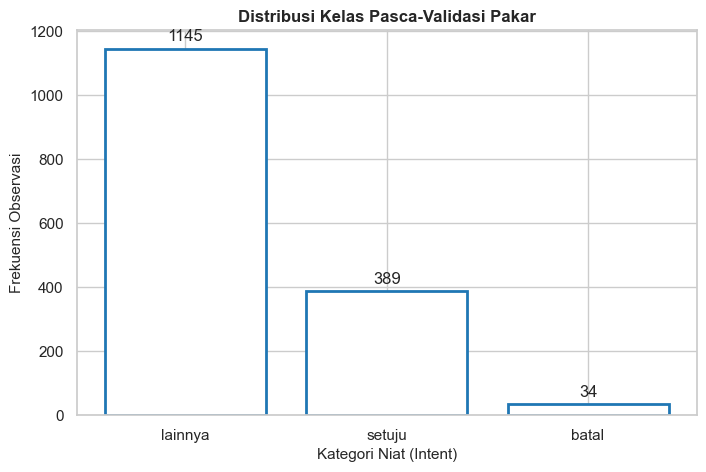

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("=== TAHAP 6: ANALISIS DATA EKSPLORATIF PASCA-VALIDASI ===")

# 1. Memuat dataset pasca-verifikasi pakar
df_validated = pd.read_csv('data_mentah_untuk_validasi.csv')

# 2. Standardisasi atribut target
df_validated.rename(columns={'Label_Validasi': 'intent'}, inplace=True)

# 3. Normalisasi tipografi untuk mengantisipasi ketidakkonsistenan *data entry*
df_validated['intent'] = df_validated['intent'].astype(str).str.lower().str.strip()

print("Variasi kelas yang divalidasi:")
print(df_validated['intent'].unique())
print("-" * 40)

# 4. Tabulasi frekuensi sebaran Ground Truth
print("--- Distribusi Kelas Empiris (Ground Truth) ---")
dist = df_validated['intent'].value_counts()
print(dist)

# 5. Konstruksi visualisasi statistik distribusi
intents = dist.index.tolist()
freq = dist.values.tolist()

fig, ax = plt.subplots(figsize=(8, 5))
# Visualisasi akademik: bar polos (facecolor='white') dengan garis tepi berwarna (edgecolor)
rects = ax.bar(intents, freq, label='Ground Truth', facecolor='white', edgecolor='#1f77b4', linewidth=2)
ax.set_ylabel('Frekuensi Observasi', fontsize=11)
ax.set_xlabel('Kategori Niat (Intent)', fontsize=11)
ax.set_title('Distribusi Kelas Pasca-Validasi Pakar', fontsize=12, fontweight='bold')

for rect in rects:
    height = rect.get_height()
    ax.annotate(f'{height}', xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')
plt.show()

## 7. Integrasi Data Eksternal (*External Data Integration*)

**Tujuan:** Memperkaya dataset dengan menambahkan observasi dari sumber eksternal (data kuesioner dan riwayat WhatsApp terbaru) guna meningkatkan jumlah sampel dan kualitas pemodelan.
**Prosedur:** 
1. Mengimpor observasi dari `dataset_kusioner.csv` dan `data_baru_dari_wa_clean.csv`.
2. Menerapkan fungsi pra-pemrosesan teks (`clean_text`) yang terstandardisasi.
3. Menggabungkan data eksternal dengan dataset utama.
4. Memvisualisasikan komparasi distribusi kelas sebelum dan sesudah integrasi dalam format monokrom (hitam-putih).

=== TAHAP 7: INTEGRASI DATA EKSTERNAL ===
Data eksternal berhasil dimuat: 54 observasi.

Integrasi berhasil. Total observasi saat ini: 1622

--- Distribusi Kelas Pasca-Integrasi ---
intent
lainnya    1161
setuju      411
batal        49
nan           1
Name: count, dtype: int64


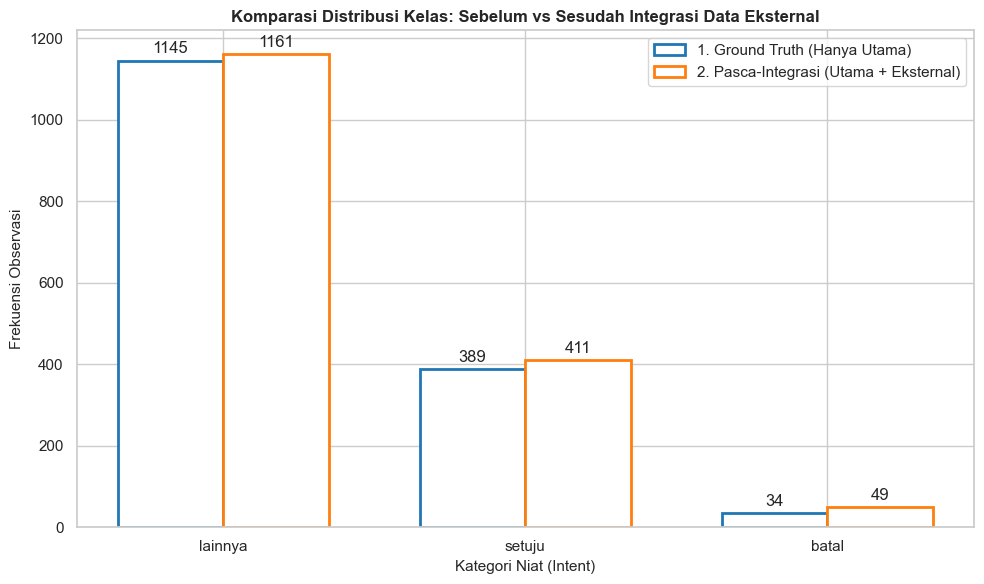

In [23]:
print("=== TAHAP 7: INTEGRASI DATA EKSTERNAL ===")

# 1. Memuat dataset eksternal
df_kusioner = pd.read_csv('dataset_kusioner.csv')
df_wa_baru = pd.read_csv('data_baru_dari_wa_clean.csv')

# 2. Menggabungkan dataset eksternal menjadi satu entitas
df_external = pd.concat([df_kusioner, df_wa_baru], ignore_index=True)

# 3. Menerapkan pembersihan teks menggunakan fungsi clean_text 
df_external['clean_text'] = df_external['text'].apply(clean_text)
df_external['intent'] = df_external['intent'].astype(str).str.lower().str.strip()
df_external['source'] = 'external'

print(f"Data eksternal berhasil dimuat: {len(df_external)} observasi.")

# 4. Integrasi dengan dataset utama
df_main = df_validated.copy()
if 'Teks_Asli' in df_main.columns:
    df_main.rename(columns={'Teks_Asli': 'text', 'Cleaned_Message': 'clean_text'}, inplace=True)
df_main['source'] = 'main'

df_combined = pd.concat([df_main[['text', 'clean_text', 'intent', 'source']], 
                         df_external[['text', 'clean_text', 'intent', 'source']]], ignore_index=True)

print(f"\nIntegrasi berhasil. Total observasi saat ini: {len(df_combined)}")

# 5. Visualisasi Perbandingan (Ground Truth vs Pasca-Integrasi)
print("\n--- Distribusi Kelas Pasca-Integrasi ---")
print(df_combined['intent'].value_counts())

intents = ['lainnya', 'setuju', 'batal']
freq_main = [len(df_main[df_main['intent']==i]) for i in intents]
freq_combined = [len(df_combined[df_combined['intent']==i]) for i in intents]

x = np.arange(len(intents))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
# Visualisasi komparasi akademik: bar polos dengan warna garis tepi yang berbeda
rects1 = ax.bar(x - width/2, freq_main, width, label='1. Ground Truth (Hanya Utama)', facecolor='white', edgecolor='#1f77b4', linewidth=2)
rects2 = ax.bar(x + width/2, freq_combined, width, label='2. Pasca-Integrasi (Utama + Eksternal)', facecolor='white', edgecolor='#ff7f0e', linewidth=2)

ax.set_ylabel('Frekuensi Observasi', fontsize=11)
ax.set_xlabel('Kategori Niat (Intent)', fontsize=11)
ax.set_title('Komparasi Distribusi Kelas: Sebelum vs Sesudah Integrasi Data Eksternal', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(intents)
ax.legend()

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        if height > 0:
            ax.annotate(f'{height}', xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)
fig.tight_layout()
plt.show()

## 8. Penyeimbangan Distribusi Data (*Data Balancing*)

**Tujuan:** Mengelola ketimpangan representasi kelas (*class imbalance*) yang berpotensi menghasilkan bias pada pemodelan prediksi.
**Prosedur:** 
Menerapkan teknik *Undersampling* pada kelas mayoritas (`lainnya`) untuk mereduksi observasi hingga mencapai target keseimbangan (800 sampel). Kelas minoritas dibiarkan utuh (*as is*) sebagai fondasi data riwayat yang murni.

=== TAHAP 8: UNDERSAMPLING KELAS MAYORITAS ===
✅ Proses Undersampling berhasil diterapkan (Target Mayoritas: 800).
- Proporsi kelas 'lainnya' terkini : 800 observasi.
- Proporsi kelas 'setuju'          : 411 observasi.
- Proporsi kelas 'batal'           : 49 observasi.

--- Distribusi Kelas Final (Pasca-Undersampling) ---
intent
lainnya    800
setuju     411
batal       49
Name: count, dtype: int64


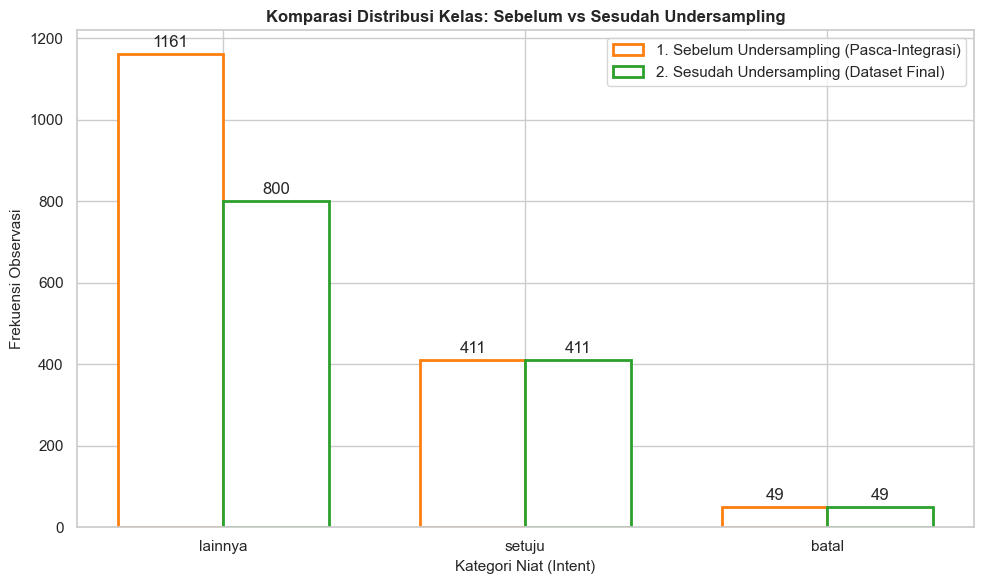

In [24]:
print("=== TAHAP 8: UNDERSAMPLING KELAS MAYORITAS ===")

TARGET_SAMPLES = 800

# 1. Segmentasi data berdasarkan kategori niat
df_lainnya = df_combined[df_combined['intent'] == 'lainnya'].copy()
df_setuju = df_combined[df_combined['intent'] == 'setuju'].copy()
df_batal = df_combined[df_combined['intent'] == 'batal'].copy()

# 2. Menerapkan undersampling acak pada kelas yang melampaui batas target
if len(df_lainnya) > TARGET_SAMPLES:
    df_lainnya = df_lainnya.sample(n=TARGET_SAMPLES, random_state=42)

# 3. Integrasi ulang observasi untuk membentuk dataset terpadu
df_final = pd.concat([df_lainnya, df_setuju, df_batal], ignore_index=True)

print(f"✅ Proses Undersampling berhasil diterapkan (Target Mayoritas: {TARGET_SAMPLES}).")
print(f"- Proporsi kelas 'lainnya' terkini : {len(df_lainnya)} observasi.")
print(f"- Proporsi kelas 'setuju'          : {len(df_setuju)} observasi.")
print(f"- Proporsi kelas 'batal'           : {len(df_batal)} observasi.")

# 4. Visualisasi Komparasi Distribusi Final
print("\n--- Distribusi Kelas Final (Pasca-Undersampling) ---")
print(df_final['intent'].value_counts())

intents = ['lainnya', 'setuju', 'batal']
freq_combined = [len(df_combined[df_combined['intent']==i]) for i in intents]
freq_final = [len(df_final[df_final['intent']==i]) for i in intents]

x = np.arange(len(intents))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
# Visualisasi komparasi akademik: bar polos dengan warna garis tepi yang berbeda
rects1 = ax.bar(x - width/2, freq_combined, width, label='1. Sebelum Undersampling (Pasca-Integrasi)', facecolor='white', edgecolor='#ff7f0e', linewidth=2)
rects2 = ax.bar(x + width/2, freq_final, width, label='2. Sesudah Undersampling (Dataset Final)', facecolor='white', edgecolor='#2ca02c', linewidth=2)

ax.set_ylabel('Frekuensi Observasi', fontsize=11)
ax.set_xlabel('Kategori Niat (Intent)', fontsize=11)
ax.set_title('Komparasi Distribusi Kelas: Sebelum vs Sesudah Undersampling', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(intents)
ax.legend()

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        if height > 0:
            ax.annotate(f'{height}', xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)
fig.tight_layout()
plt.show()

## 9. Ekspor Dataset Final

Dataset yang telah terintegrasi dan di-*undersample* diekspor ke dalam format CSV untuk dipergunakan pada tahapan ekstraksi fitur dan pelatihan model algoritma klasifikasi.

In [25]:
print("=== TAHAP 9: EKSPOR DATASET FINAL ===")

file_final = 'dataset_prepared_final.csv'
df_final.to_csv(file_final, index=False)

print(f"✅ HASIL: Dataset final berhasil diekspor sebagai '{file_final}'.")

=== TAHAP 9: EKSPOR DATASET FINAL ===
✅ HASIL: Dataset final berhasil diekspor sebagai 'dataset_prepared_final.csv'.
